In [1]:
#####let's see the output

In [16]:
def loadall2cube(cumfile, extracols=['loop_ph_avg_abs']):
    cumdir = os.path.dirname(cumfile)
    cohfile = os.path.join(cumdir,'results/coh_avg')
    rmsfile = os.path.join(cumdir,'results/resid_rms')
    vstdfile = os.path.join(cumdir,'results/vstd')
    stcfile = os.path.join(cumdir,'results/stc')
    maskfile = os.path.join(cumdir,'results/mask')
    metafile = os.path.join(cumdir,'../../metadata.txt')
    #h5datafile = 'cum.h5'
    cum = xr.load_dataset(cumfile)
    
    sizex = len(cum.vel[0])
    sizey = len(cum.vel)
    
    lon = cum.corner_lon.values+cum.post_lon.values*np.arange(sizex)-0.5*float(cum.post_lon)
    lat = cum.corner_lat.values+cum.post_lat.values*np.arange(sizey)+0.5*float(cum.post_lat)  # maybe needed? yes! for gridline/AREA that is default in rasterio...
    
    time = np.array(([dt.datetime.strptime(str(imd), '%Y%m%d') for imd in cum.imdates.values]))
    
    velxr = xr.DataArray(cum.vel.values.reshape(sizey,sizex), coords=[lat, lon], dims=["lat", "lon"])
    #LiCSBAS uses 0 instead of nans...
    velxr = velxr.where(velxr!=0)
    velxr.attrs['unit'] = 'mm/year'
    #vinterceptxr = xr.DataArray(cum.vintercept.values.reshape(sizey,sizex), coords=[lat, lon], dims=["lat", "lon"])
    
    cumxr = xr.DataArray(cum.cum.values, coords=[time, lat, lon], dims=["time","lat", "lon"])
    cumxr.attrs['unit'] = 'mm'
    #bperpxr = xr.DataArray(cum.bperp.values, coords=[time], dims=["time"])
    
    cube = xr.Dataset()
    cube['cum'] = cumxr
    cube['vel'] = velxr
    
    # Load Ionospheric correction (iono) from cum.h5 if it exists
    if 'iono' in cum:
        ionoxr = xr.DataArray(cum.iono.values.reshape(cum.cum.shape), 
                              coords=[time, lat, lon], dims=["time", "lat", "lon"])
        ionoxr = ionoxr.where(ionoxr != 0)  # Replace zeros with NaNs
        ionoxr.attrs['unit'] = 'mm'
        cube['iono'] = ionoxr
    else:
        print('No iono data found in cum.h5, skipping')

    # Load Solid Earth Tides correction (tide) from cum.h5 if it exists
    if 'tide' in cum:
        tidexr = xr.DataArray(cum.tide.values.reshape(cum.cum.shape), 
                              coords=[time, lat, lon], dims=["time", "lat", "lon"])
        tidexr = tidexr.where(tidexr != 0)  # Replace zeros with NaNs
        tidexr.attrs['unit'] = 'mm'
        cube['tide'] = tidexr
    else:
        print('No tide data found in cum.h5, skipping')
    
    #cube['vintercept'] = vinterceptxr
    try:
        cube['bperp'] = xr.DataArray(cum.bperp.values, coords=[time], dims=["time"])
        cube['bperp'] = cube.bperp.where(cube.bperp!=0)
        # re-ref it to the first date
        if np.isnan(cube['bperp'][0]):
            firstbperp = 0
        else:
            firstbperp = cube['bperp'][0]
        cube['bperp'] = cube['bperp'] - firstbperp
        cube['bperp'] = cube.bperp.astype(np.float32)
        cube.bperp.attrs['unit'] = 'm'
    except:
        print('some error loading bperp info')
    
    #if 'mask' in cum:
    #    # means this is filtered version, i.e. cum_filt.h5
    cube.attrs['filtered_version'] = 'mask' in cum
    
    #add coh_avg resid_rms vstd
    if os.path.exists(cohfile):
        infile = np.fromfile(cohfile, 'float32')
        cohxr = xr.DataArray(infile.reshape(sizey,sizex), coords=[lat, lon], dims=["lat", "lon"])
        cube['coh'] = cohxr
        cube.coh.attrs['unit']='unitless'
    else: print('No coh_avg file detected, skipping')
    if os.path.exists(rmsfile):
        infile = np.fromfile(rmsfile, 'float32')
        rmsxr = xr.DataArray(infile.reshape(sizey,sizex), coords=[lat, lon], dims=["lat", "lon"])
        rmsxr.attrs['unit'] = 'mm'
        cube['rms'] = rmsxr
    else: print('No RMS file detected, skipping')
    try:
        for e in extracols:
            efile=os.path.join(cumdir,'results',e)
            if os.path.exists(efile):
                infile = np.fromfile(efile, 'float32')   # should be always float. but we can check with os.stat('loop_ph_avg_abs').st_size
                exr = xr.DataArray(infile.reshape(sizey, sizex), coords=[lat, lon], dims=["lat", "lon"])
                #rmsxr.attrs['unit'] = 'mm'
                cube[e] = exr
            else:
                print('No '+e+' file detected, skipping')
    except:
        print('debug - extra layers not included')
    if os.path.exists(vstdfile):
        infile = np.fromfile(vstdfile, 'float32')
        vstdxr = xr.DataArray(infile.reshape(sizey,sizex), coords=[lat, lon], dims=["lat", "lon"])
        vstdxr.attrs['unit'] = 'mm/year'
        cube['vstd'] = vstdxr
    else: print('No vstd file detected, skipping')
    if os.path.exists(stcfile):
        infile = np.fromfile(stcfile, 'float32')
        stcxr = xr.DataArray(infile.reshape(sizey,sizex), coords=[lat, lon], dims=["lat", "lon"])
        stcxr.attrs['unit'] = 'mm'
        cube['stc'] = stcxr
    else: print('No stc file detected, skipping')
    if os.path.exists(maskfile):
        infile = np.fromfile(maskfile, 'float32')
        #infile = np.nan_to_num(infile,0).astype(int)  # change nans to 0
        infile = np.nan_to_num(infile,0).astype(np.int8)  # change nans to 0
        maskxr = xr.DataArray(infile.reshape(sizey,sizex), coords=[lat, lon], dims=["lat", "lon"])
        maskxr.attrs['unit'] = 'unitless'
        cube['mask'] = maskxr
    else: print('No mask file detected, skipping')
    # add inc_angle
    if os.path.exists(metafile):
        #a = subp.run(['grep','inc_angle', metafile], stdout=subp.PIPE)
        #inc_angle = float(a.stdout.decode('utf-8').split('=')[1])
        inc_angle = float(grep1line('inc_angle',metafile).split('=')[1])
        cube.attrs['inc_angle'] = inc_angle
    else: print('')#'warning, metadata file not found. using general inc angle value')
        #inc_angle = 39
    
    #cube['bperp'] = bperpxr
    #cube[]
    cube.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)
    cube.rio.write_crs("EPSG:4326", inplace=True)
    cube = cube.sortby(['time','lon','lat'])
    return cube

In [2]:
def load_licsbas_cumh5_as_xrda(cumfile):
    ''' Loads cum.h5 (now only cum layer) as standard xr.DataArray (in lon/lat)'''
    cum = xr.load_dataset(cumfile)
    #
    sizex = len(cum.vel[0])
    sizey = len(cum.vel)
    #
    lon = cum.corner_lon.values + cum.post_lon.values * np.arange(sizex) - 0.5 * float(cum.post_lon)
    lat = cum.corner_lat.values + cum.post_lat.values * np.arange(sizey) + 0.5 * float(cum.post_lat)  # maybe needed? yes! for gridline/AREA that is default in rasterio...
    #
    time = np.array(([dt.datetime.strptime(str(imd), '%Y%m%d') for imd in cum.imdates.values]))
    #
    velxr = xr.DataArray(cum.vel.values.reshape(sizey, sizex), coords=[lat, lon], dims=["lat", "lon"])
    # LiCSBAS uses 0 instead of nans...
    velxr = velxr.where(velxr != 0)
    velxr.attrs['unit'] = 'mm/year'
    # vinterceptxr = xr.DataArray(cum.vintercept.values.reshape(sizey,sizex), coords=[lat, lon], dims=["lat", "lon"])
    #
    cumxr = xr.DataArray(cum.cum.values, coords=[time, lat, lon], dims=["time", "lat", "lon"])
    cumxr.attrs['unit'] = 'mm'
    refarea = str(cum.refarea.values)
    # x is first...
    refx1 = int(refarea.split('/')[0].split(':')[0])
    refx2 = int(refarea.split('/')[0].split(':')[1])
    refy1 = int(refarea.split('/')[1].split(':')[0])
    refy2 = int(refarea.split('/')[1].split(':')[1])
    refx=int((refx2+refx1)/2)
    refy = int((refy2 + refy1) / 2)
    cumxr.attrs['ref_lon'] = cumxr.lon.values[refx]
    cumxr.attrs['ref_lat'] = cumxr.lat.values[refy]
    return cumxr


In [1]:
from lics_unwrap import *
import re, os, glob
import xarray as xr
from scipy.constants import speed_of_light
import h5py
import numpy as np

setting pyproj data directory


In [8]:
frame=['014A_04920_161613', '014A_05232_242525','021D_05266_252525', '116A_05207_252525']

cumfile=f'/work/scratch-pw2/licsar/mnergiz/{frame[0]}/TS_GEOCml10/cum.h5'
ncfile=f'/work/scratch-pw2/licsar/mnergiz/{frame[0]}/{frame[0]}.nc'

In [10]:
# cumhdfile=cumfile
# cumxr = load_licsbas_cumh5_as_xrda(cumhdfile)
# tifdir = '/work/scratch-pw2/licsar/mnergiz/014A_04920_161613/GEOC.EPOCHS'
# ext='tide.geo.azi.tif'
# sbovl=True
# tif_scale2mm = 1000
# only_load_ext = True
# cumxr_tide=xr.zeros_like(cumxr)
# i=0
# cumepoch = cumxr[i]
# epoch = str(cumepoch.time.values).split('T')[0].replace('-','')
# extif = os.path.join(tifdir, epoch, epoch+'.'+ext)
# print(epoch, extif)
# if not os.path.exists(extif):
#     extif = os.path.join(tifdir, epoch + '.' + ext)
# if not os.path.exists(extif):
#     print('\n\r WARNING: no correction available for epoch '+epoch+'. Filling with NaNs')
#     extepoch = cumepoch.copy() * np.nan
#     extepoch.attrs.clear()
# else:
#     print('here we go!')
#     extepoch = load_tif2xr(extif)
#     extepoch = extepoch.where(extepoch != 0) # just in case...
#     extepoch = extepoch * tif_scale2mm
#     extepoch = extepoch.interp_like(cumepoch, method='linear') # CHECK!
#     if not sbovl:
#         extepoch = extepoch - extepoch.sel(lon=reflon, lat=reflat, method='nearest') # could be done better though
# if i == 0:
#     firstepvals = extepoch.fillna(0).values
# # here we do diff w.r.t. first epoch
# extepoch.values = extepoch.values - firstepvals
# cumxr_tide.values[i] = extepoch.values


In [72]:
cumhdfile=cumfile
cumxr = load_licsbas_cumh5_as_xrda(cumhdfile)
tifdir = '/work/scratch-pw2/licsar/mnergiz/014A_04920_161613/GEOC.EPOCHS'
ext='tide.geo.azi.tif'
sbovl=True
tif_scale2mm = 1000
only_load_ext = True
cumxr_tide=xr.zeros_like(cumxr)

reflon, reflat = cumxr.attrs['ref_lon'], cumxr.attrs['ref_lat']
#
firstepvals = 0
leneps = len(cumxr)
print(leneps)
for i in range(leneps): # times first coord..
    print('  Running for {0:6}/{1:6}th epoch'.format(i+1, leneps), flush=True, end='\r')
    cumepoch = cumxr[i]
    epoch = str(cumepoch.time.values).split('T')[0].replace('-','')
    extif = os.path.join(tifdir, epoch, epoch+'.'+ext)
    if not os.path.exists(extif):
        extif = os.path.join(tifdir, epoch + '.' + ext)
    if not os.path.exists(extif):
        print('\n\r WARNING: no correction available for epoch '+epoch+'. Filling with NaNs')
        extepoch = cumepoch.copy() * np.nan
        extepoch.attrs.clear()
    else:
        extepoch = load_tif2xr(extif)
        extepoch = extepoch.where(extepoch != 0) # just in case...
        extepoch = extepoch * tif_scale2mm
        extepoch = extepoch.interp_like(cumepoch, method='linear') # CHECK!
        if not sbovl:
            extepoch = extepoch - extepoch.sel(lon=reflon, lat=reflat, method='nearest') # could be done better though
    if i == 0:
        firstepvals = extepoch.fillna(0).values
    # here we do diff w.r.t. first epoch
    extepoch.values = extepoch.values - firstepvals
    # mask that - not needed (?)
    #extepoch = extepoch.where(~np.isnan(cumxr[i]))
    if only_load_ext:
        cumxr_tide.values[i] = extepoch.values
    else:
        cumxr_tide.values[i] = cumxr.values[i] - extepoch.values

61


In [122]:
cumhdfile=cumfile
cumxr = load_licsbas_cumh5_as_xrda(cumhdfile)
tifdir = '/work/scratch-pw2/licsar/mnergiz/014A_04920_161613/GEOC.EPOCHS'
ext='geo.iono.code.sTECA.tif'
sbovl=True
tif_scale2mm = 1000
only_load_ext = True
cumxr_iono=xr.zeros_like(cumxr)

reflon, reflat = cumxr.attrs['ref_lon'], cumxr.attrs['ref_lat']
#
firstepvals = 0
leneps = len(cumxr)
print(leneps)
for i in range(leneps): # times first coord..
    print('  Running for {0:6}/{1:6}th epoch'.format(i+1, leneps), flush=True, end='\r')
    cumepoch = cumxr[i]
    epoch = str(cumepoch.time.values).split('T')[0].replace('-','')
    
    if 'STEC' in ext.upper():
        ext1='geo.iono.code.sTECA.tif'
        ext2='geo.iono.code.sTECB.tif'
    extif1 = os.path.join(tifdir, epoch, epoch+'.'+ext1)
    extif2 = os.path.join(tifdir, epoch, epoch+'.'+ext2)
    if not os.path.exists(extif1) or not os.path.exists(extif2):
        extif1 = os.path.join(tifdir, epoch+'.'+ext1)
        extif2 = os.path.join(tifdir, epoch+'.'+ext2)
    if not os.path.exists(extif1) or not os.path.exists(extif2):
        print('\n\r WARNING: no correction available for epoch '+epoch+'. Filling with NaNs')
        ##backward
        extepoch1 = cumepoch.copy() * np.nan
        extepoch1.attrs.clear()
        #forward
        extepoch2 = cumepoch.copy() * np.nan
        extepoch2.attrs.clear()
    else:
        #backward
        extepoch1 = load_tif2xr(extif1)
        extepoch1 = extepoch1.where(extepoch1 != 0) # just in case...
        extepoch1 = extepoch1.interp_like(cumepoch, method='linear') # CHECK! ##looks redundant so far (maybe not)
        #forward
        extepoch2 = load_tif2xr(extif2)
        extepoch2 = extepoch2.where(extepoch2 != 0)
        extepoch2 = extepoch2.interp_like(cumepoch, method='linear')
        
    ####gradient method Lazecky et al. 2023,GRL #https://github.com/comet-licsar/daz/blob/main/lib/daz_iono.py#L561
    ###parameter for TEC gradient
    azpix=14000
    PRF = 486.486
    k = 40.308193 # m^3 / s^2
    f0 = 5.4050005e9
    c = speed_of_light
    
    ##scaling_tif
    frame='014A_04920_161613'
    metafolder = os.path.join(os.environ['LiCSAR_public'], str(int(frame[:3])), frame, 'metadata')
    # Check if the metadata folder exists
    if os.path.exists(metafolder) and os.path.isdir(metafolder):
        scaling_tif = None  # Initialize variable to track if a file is found
        
        for files in os.listdir(metafolder):  
            if files.endswith('.geo.sbovl_scaling.tif'):
                scaling_tif = os.path.join(metafolder, files)
        # Check if no scaling file was found
        if scaling_tif is None:
            print("No .geo.sbovl_scaling.tif file found in metadata folder.")
    else:
        print(f"metadata is not exist in LiCSAR_public")  
    
    ##scaling2dfdc
    scaling_factor=load_tif2xr(scaling_tif)
    scaling_factor = scaling_factor.interp_like(cumepoch, method='linear')
    dfDC=azpix*PRF/(2*np.pi*scaling_factor)
    fH = f0 + dfDC*0.5
    fL = f0 - dfDC*0.5
    tecovl=(extepoch1/fH-extepoch2/fL)
    iono_grad = 2*PRF*k/c/dfDC * tecovl #unitless
    iono_grad_mm=iono_grad*azpix #mm
    
    
    if i == 0:
        firstepvals = iono_grad_mm.fillna(0).values
    # here we do diff w.r.t. first epoch
    iono_grad_mm.values = iono_grad_mm.values - firstepvals
    
    if only_load_ext:
        cumxr_iono.values[i] = iono_grad_mm.values
    else:
        cumxr.values[i] = cumxr.values[i] - iono_grad_mm.values


61


In [131]:
export_xr2tif(cumxr_iono[16],f'trial_iono3_mm.tif')

/gws/smf/j04/nceo_geohazards/software/mambalics/lib/python3.8/site-packages/xarray/core/dataarray.py:866: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  return key in self.data
mv: cannot stat 'trial_iono3_mm.tif': No such file or directory


WARNING - command did not exit as OK


In [132]:
export_xr2tif(cumxr_tide[16],f'trial_tide3_mm.tif')

/gws/smf/j04/nceo_geohazards/software/mambalics/lib/python3.8/site-packages/xarray/core/dataarray.py:866: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  return key in self.data
mv: cannot stat 'trial_tide3_mm.tif': No such file or directory


WARNING - command did not exit as OK


In [133]:
export_xr2tif(cumxr[16],f'trial3_mm.tif')

/gws/smf/j04/nceo_geohazards/software/mambalics/lib/python3.8/site-packages/xarray/core/dataarray.py:866: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  return key in self.data
mv: cannot stat 'trial3_mm.tif': No such file or directory


WARNING - command did not exit as OK


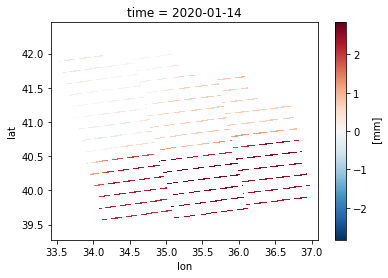

In [129]:
cumxr_iono[2].plot()

In [127]:
cumxr_iono

<xarray.DataArray (time: 61, lat: 318, lon: 368)>
array([[[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ..., 
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ..., 
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ..., 
...
        ..., 
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ..., 
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ..., 
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 2020-01-02 2020-01-08 ... 2020-12-27
  * lat      (lat) float64 42.45 42.44 42.43 42.42 ... 39.31 39.3 39.29 39.28
  * lon      (lon) float64 33.42 33.43 33.44 33.45 ... 37.06 37.07 37.08 37.09
Attributes:
    unit:     mm
    ref_lon:  35.0180556
    ref_lat:  40.1016666

In [97]:
extepoch2_interp = extepoch2.interp_like(cumepoch, method='linear')

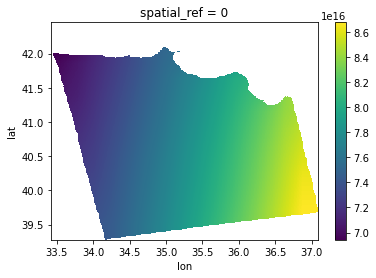

In [98]:
extepoch2_interp.plot()

In [102]:
scaling_factor

<xarray.DataArray (lat: 3184, lon: 3688)>
array([[ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       ..., 
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan]], dtype=float32)
Coordinates:
  * lon          (lon) float64 33.42 33.42 33.43 33.43 ... 37.11 37.11 37.11
  * lat          (lat) float64 42.46 42.46 42.45 42.45 ... 39.28 39.27 39.27
    spatial_ref  int64 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0

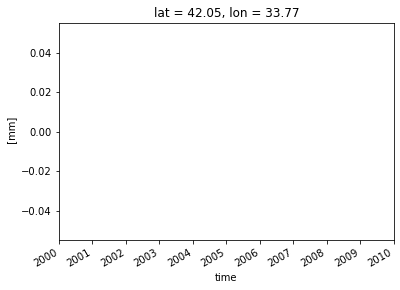

In [85]:

# Extract the time series using isel()
cumxr_tide.isel(lat=40, lon=35).plot()

# # Plot the time series using isel()
# plt.figure(figsize=(10, 5))
# plt.plot(tide_series_isel.time, tide_series_isel.values, marker="o", linestyle="-", label="Tide Correction (isel)")
# plt.xlabel("Time")
# plt.ylabel("Displacement (mm)")
# plt.title(f"Tide Correction Time Series using isel() at index ({lat_index}, {lon_index})")
# plt.grid(True)
# plt.legend()
# plt.xticks(rotation=45)
# plt.show()


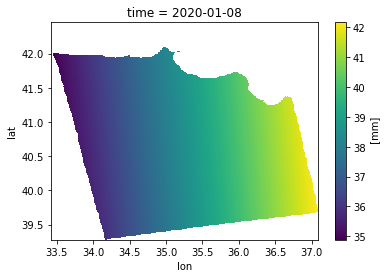

In [88]:
cumxr_tide[1].plot()

In [23]:
np.nanmin(cumxr[0].data)

0.0

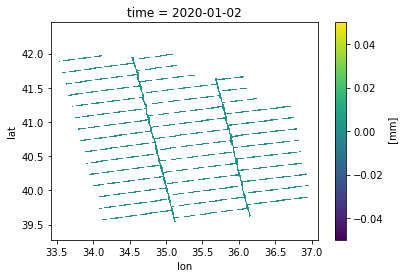

In [11]:
cumxr[0].plot()

In [12]:
cumxr

<xarray.DataArray (time: 61, lat: 318, lon: 368)>
array([[[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ..., 
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ..., 
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ..., 
...
        ..., 
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ..., 
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]],

       [[ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        ..., 
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan],
        [ nan,  nan,  nan, ...,  nan,  nan,  nan]]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 2020-01-02 2020-01-08 ... 2020-12-27
  * lat      (lat) float64 42.45 42.44 42.43 42.42 ... 39.31 39.3 39.29 39.28
  * lon      (lon) float64 33.42 33.43 33.44 33.45 ... 37.06 37.07 37.08 37.09
Attributes:
    unit:     mm
    ref_lon:  35.0180556
    ref_lat:  40.1016666

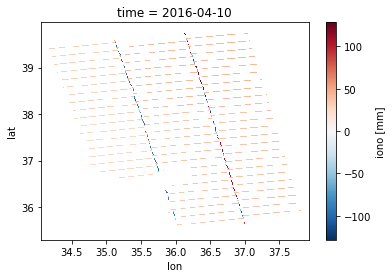

In [36]:
dn['iono'][6].plot()

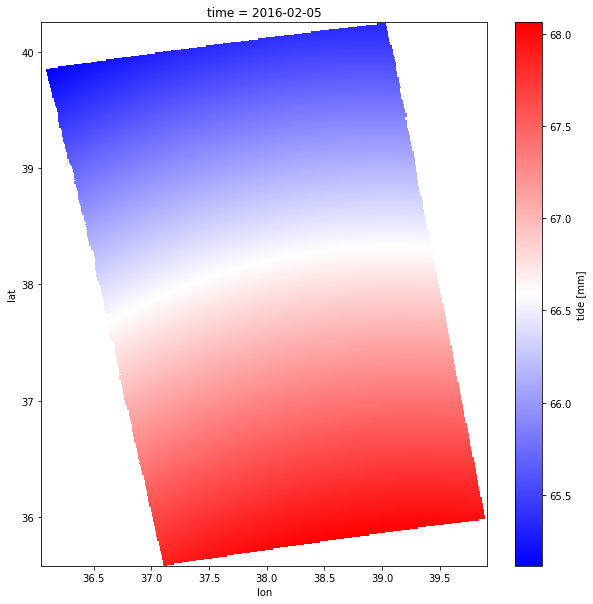

In [17]:
dn['tide'][2].plot(cmap='bwr', figsize=(10,10))

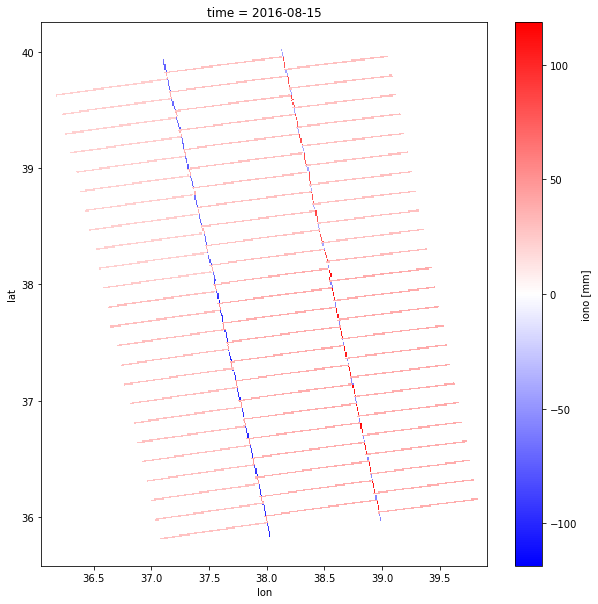

In [23]:
dn['iono'][16].plot(cmap='bwr', figsize=(10,10))

In [19]:
dn['iono'][2]

<xarray.DataArray 'iono' (lat: 468, lon: 387)>
array([[ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       ..., 
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan]], dtype=float32)
Coordinates:
    time     datetime64[ns] 2016-02-05
  * lat      (lat) float64 35.58 35.59 35.6 35.61 ... 40.22 40.23 40.24 40.25
  * lon      (lon) float64 36.05 36.06 36.07 36.08 ... 39.88 39.89 39.9 39.91
Attributes:
    unit:          mm
    grid_mapping:  spatial_ref

In [24]:
export_xr2tif(dn['iono'][16],f'trial_iono2_mm.tif')

/gws/smf/j04/nceo_geohazards/software/mambalics/lib/python3.8/site-packages/xarray/core/dataarray.py:866: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  return key in self.data


WARNING - command did not exit as OK


mv: cannot stat 'trial_iono2_mm.tif': No such file or directory


In [215]:
reflon, reflat = dn.attrs['ref_lon'], dn.attrs['ref_lat']

In [223]:
dn['cum'].sel(lon=reflon, lat=reflat, method='nearest')

<xarray.DataArray 'cum' (time: 61)>
array([ nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 2020-01-02 2020-01-08 ... 2020-12-27
    lat      float64 39.46
    lon      float64 35.26
Attributes:
    grid_mapping:  spatial_ref

In [219]:
dn['tide'].sel(lon=reflon, lat=reflat, method='nearest')

<xarray.DataArray 'tide' (time: 61)>
array([        nan,  0.02347755,  0.00987053,  0.01062584,  0.02547598,
       -0.00067425,  0.02823067,  0.0026989 ,  0.0155201 ,  0.02194977,
       -0.00118303,  0.03017426, -0.0008316 ,  0.01630592,  0.01804161,
       -0.00236702,  0.02701783, -0.00240135,  0.01397324,  0.01388359,
       -0.00458908,  0.02113152, -0.00400734,  0.01094913,  0.00977898,
       -0.00631714,  0.01649666, -0.00539207,  0.00966525,  0.00568581,
       -0.00419426,  0.01442528, -0.00508118,  0.01120186,  0.00284386,
        0.00155163,  0.01521492, -0.00285983,  0.01548386,  0.0028801 ,
        0.00740337,  0.01835823, -0.00065756,  0.02226806,  0.00354242,
        0.01195526,  0.02177334, -0.00062943,  0.02975178,  0.00248671,
        0.01536369,  0.02333763, -0.00239182,  0.03394318,  0.00059986,
        0.01823235,  0.02194399, -0.00225258,  0.03290176, -0.00056648,
        0.02135277], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 2020-01-02 2020-01-08 ... 2020-12-27
    lat      float64 39.46
    lon      float64 35.26
Attributes:
    unit:          mm
    grid_mapping:  spatial_ref

In [220]:
dn['iono'].sel(lon=reflon, lat=reflat, method='nearest')

<xarray.DataArray 'iono' (time: 61)>
array([ nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 2020-01-02 2020-01-08 ... 2020-12-27
    lat      float64 39.46
    lon      float64 35.26
Attributes:
    unit:          mm
    grid_mapping:  spatial_ref

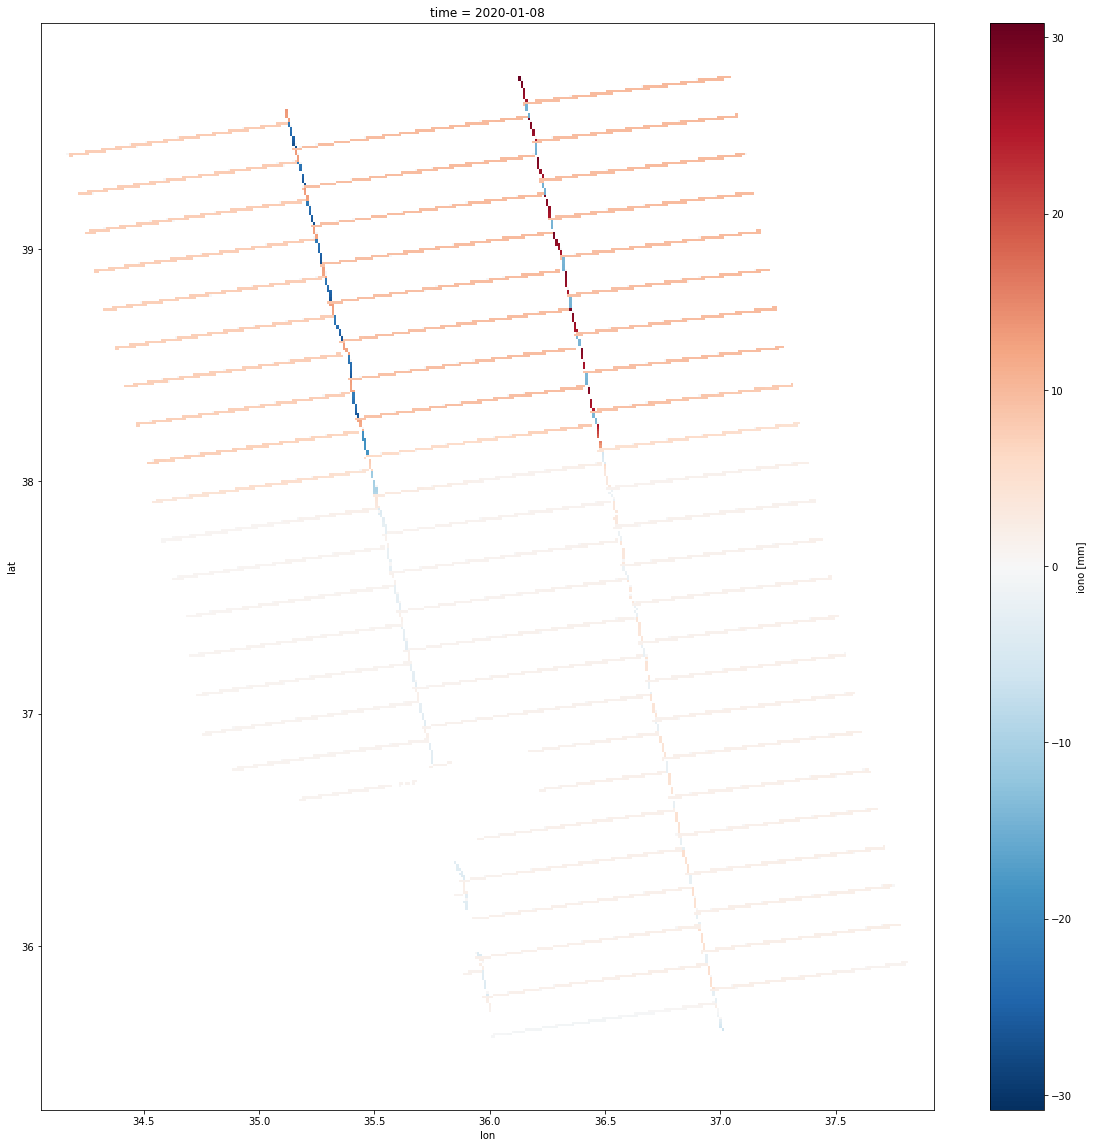

In [226]:
dn['iono'][1].plot(figsize=(20,20))

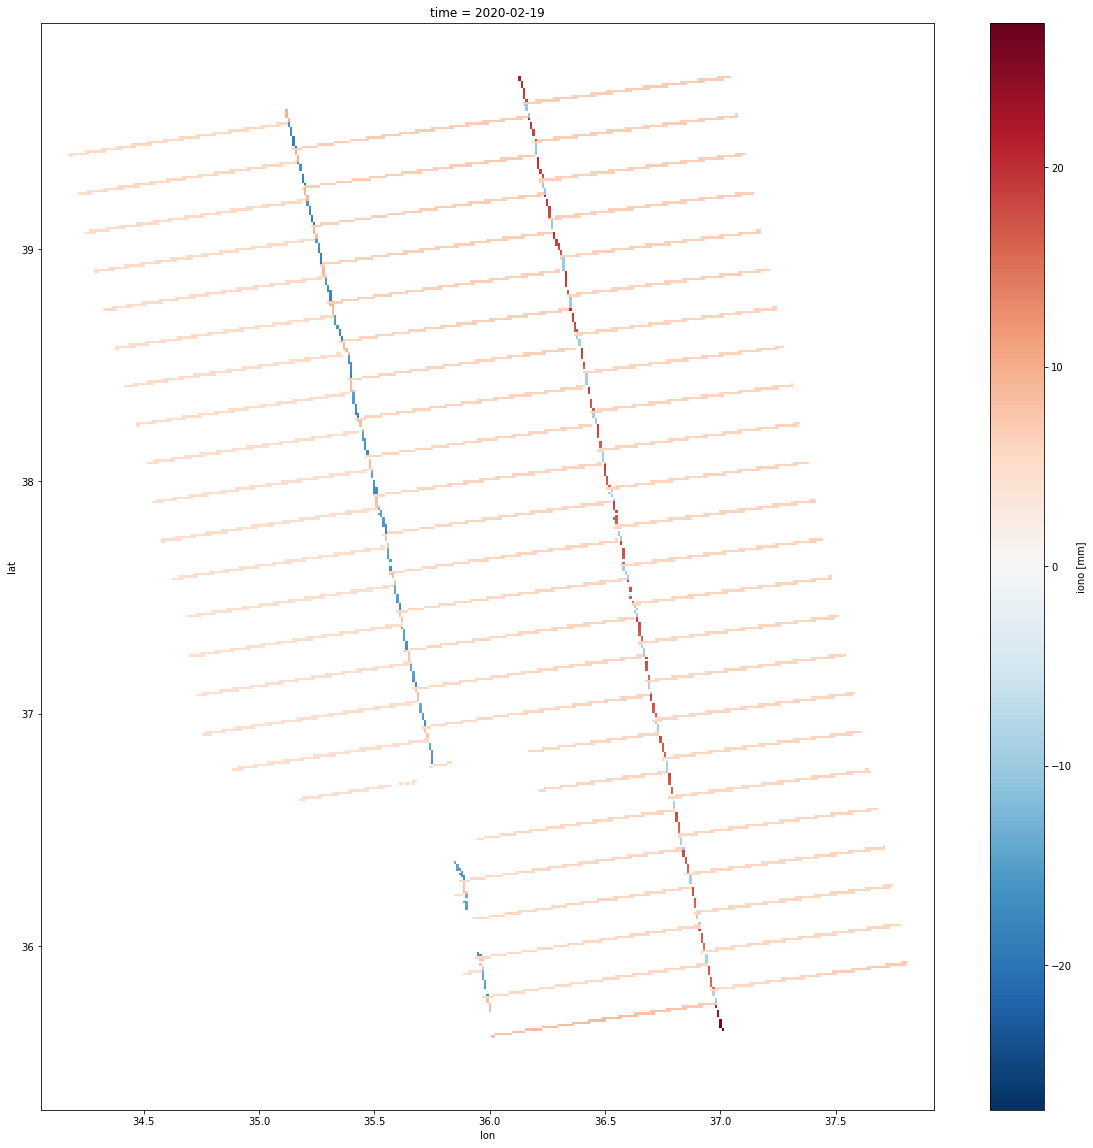

In [233]:
dn['iono'][8].plot(figsize=(20,20))

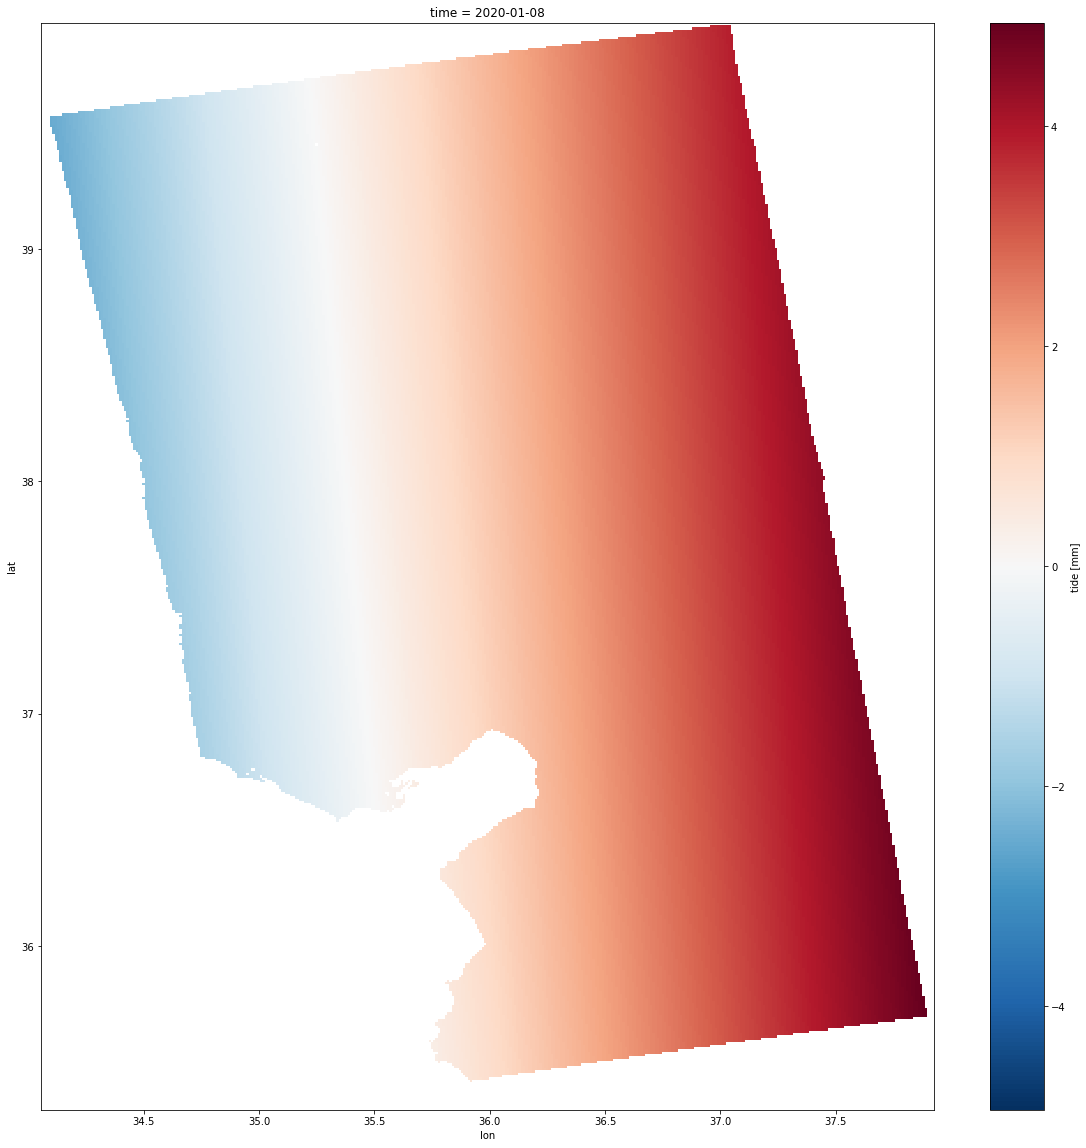

In [217]:
dn['tide'][1].plot(figsize=(20,20))

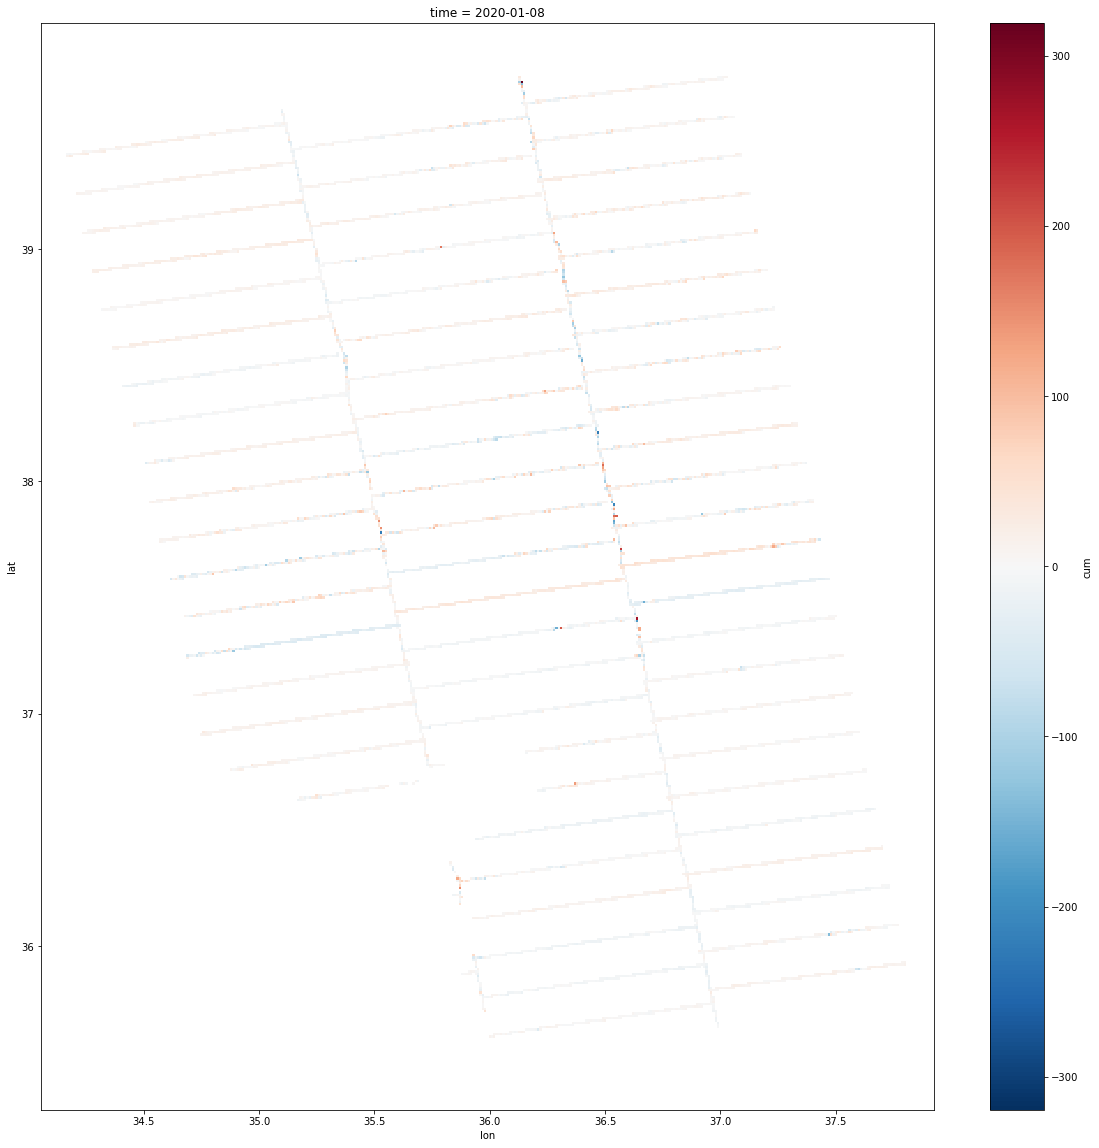

In [206]:
dn['cum'][1].plot(figsize=(20,20))

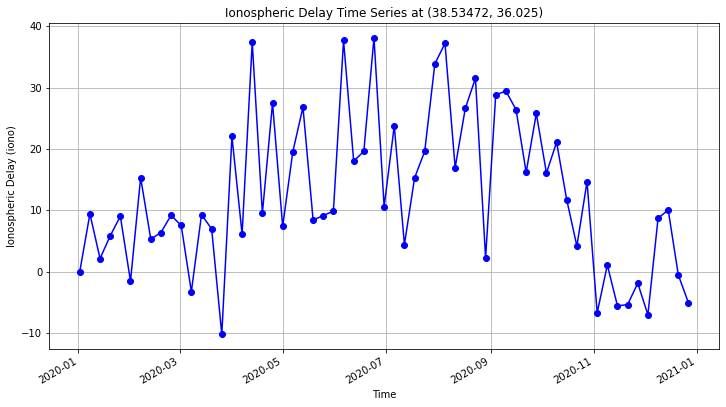

In [240]:
import matplotlib.pyplot as plt

# Define the target latitude and longitude
lat_point = 38.53472  # Example latitude
lon_point = 36.0250  # Example longitude

# Extract the time series at the given coordinate
time_series = cumxr_iono.sel(lat=lat_point, lon=lon_point, method="nearest")

# Plot the time series
plt.figure(figsize=(12, 6))
time_series.plot(marker="o", linestyle="-", color="b")

# Customize the plot
plt.title(f"Ionospheric Delay Time Series at ({lat_point}, {lon_point})")
plt.xlabel("Time")
plt.ylabel("Ionospheric Delay (iono)")
plt.grid()

# Show the plot
plt.show()


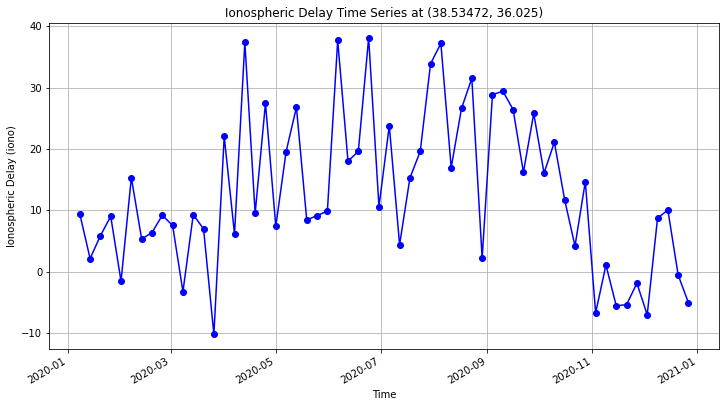

In [237]:
import matplotlib.pyplot as plt

# Define the target latitude and longitude
lat_point = 38.53472  # Example latitude
lon_point = 36.0250  # Example longitude

# Extract the time series at the given coordinate
time_series = dn["iono"].sel(lat=lat_point, lon=lon_point, method="nearest")

# Plot the time series
plt.figure(figsize=(12, 6))
time_series.plot(marker="o", linestyle="-", color="b")

# Customize the plot
plt.title(f"Ionospheric Delay Time Series at ({lat_point}, {lon_point})")
plt.xlabel("Time")
plt.ylabel("Ionospheric Delay (iono)")
plt.grid()

# Show the plot
plt.show()


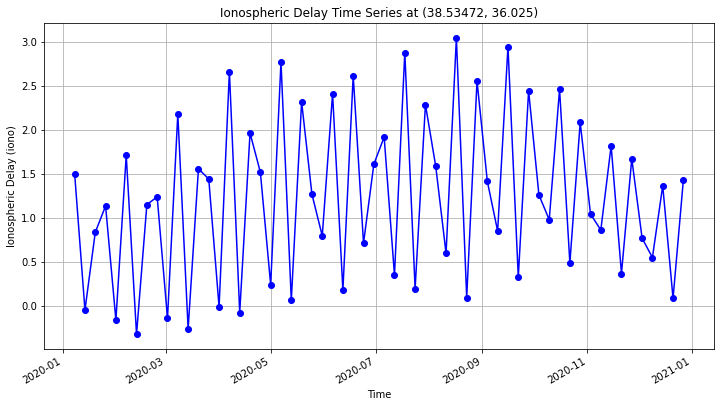

In [238]:
import matplotlib.pyplot as plt

# Define the target latitude and longitude
lat_point = 38.53472  # Example latitude
lon_point = 36.0250  # Example longitude

# Extract the time series at the given coordinate
time_series = dn["tide"].sel(lat=lat_point, lon=lon_point, method="nearest")

# Plot the time series
plt.figure(figsize=(12, 6))
time_series.plot(marker="o", linestyle="-", color="b")

# Customize the plot
plt.title(f"Ionospheric Delay Time Series at ({lat_point}, {lon_point})")
plt.xlabel("Time")
plt.ylabel("Ionospheric Delay (iono)")
plt.grid()

# Show the plot
plt.show()
